# GraphRAG 与混合检索 — 第二节
## GraphRAG & Hybrid Retrieval — Part 2

**核心主题 / Core Topic：**

> 用 Neo4j 构建知识图谱，并执行单跳、双跳、三跳图查询  
> Building a knowledge graph in Neo4j with company/person/product data,  
> then running single-hop, two-hop, and three-hop Cypher queries.

---

### 知识图谱结构预览

```
Person ──CEO_OF──▶ Company ──MAKES──▶ Product
  │                   │
  └── FOUNDED ────────┘
  │
  └── .university / .uni_city  (属性，用于多跳推理)
```

### 三种查询跳数对比

| 查询类型 | 示例问题 | 跳数 |
|----------|----------|------|
| 单跳 (Single-hop) | Apple 生产哪些产品？ | 1 |
| 双跳 (Two-hop) | Apple CEO 上哪所大学？ | 2 |
| 三跳 (Three-hop) | Apple CEO 的大学在哪个城市？ | 3 |

---

**前置条件 / Prerequisites:**
```bash
# 启动 Neo4j（Docker 方式）
docker run -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/password \
  neo4j:latest

# 安装 Python 驱动
pip install neo4j
```

---
### 📊 Slides：Knowledge Graph 基础概念

#### 三要素

```
节点 (Node)          关系 (Relationship)        属性 (Property)
────────────         ───────────────────        ─────────────────
[苹果公司]     ──EMPLOYS──>    [蒂姆·库克]       苹果公司.成立时间 = 1976
[蒂姆·库克]   ──GRADUATED──>  [奥本大学]        蒂姆·库克.职位 = "CEO"
[奥本大学]     ──LOCATED_IN──> [奥本市]          奥本大学.类型 = "公立"
[奥本市]       ──IN_STATE──>   [阿拉巴马州]
```

#### 与关系型数据库对比

|  | 关系型数据库 | 知识图谱 |
|--|------------|---------|
| 数据模型 | 表 + 外键 | 节点 + 边 |
| 多跳查询 | 多次 JOIN，性能差 | 图遍历，天然支持 |
| Schema | 固定 | 灵活 |
| 最适合 | 结构化事务 | 关系推理 |

---
### 📊为什么知识图谱能处理多跳推理

#### 例子：4 跳关系查询

**问题**："苹果公司CEO毕业的大学所在城市的市长是谁？"

```
图遍历路径（4跳）：

[苹果公司] ──CEO──> [蒂姆·库克]
                         │
                    GRADUATED_FROM
                         │
                         v
                    [奥本大学] ──LOCATED_IN──> [奥本市]
                                                    │
                                               HAS_MAYOR
                                                    │
                                                    v
                                              [Ron Anders]
```

**对应 Cypher 查询：**
```cypher
MATCH (c:Company {name: "Apple"})-[:CEO]->(p:Person)
      -[:GRADUATED_FROM]->(u:University)
      -[:LOCATED_IN]->(city:City)
      -[:HAS_MAYOR]->(mayor:Person)
RETURN mayor.name
```

> 向量检索每次只能检索单个语义片段，**无法串联多文档的推理链**；而图遍历可以在一次查询中完成所有跳转。

## step1 依赖 & 连接配置 / Import & Connection Config

In [2]:
from __future__ import annotations
from neo4j import GraphDatabase, Driver

# Neo4j 连接配置（按实际环境修改）
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"

print(f"将连接到: {NEO4J_URI}")

将连接到: bolt://localhost:7687


## step 2 — 样本数据定义 / Sample Data

我们定义三类节点（Node）：
- **Company**：公司，含成立年份、总部城市
- **Person**：人物，含职位、毕业院校及城市
- **Product**：产品，含类别和发布年份

In [3]:
COMPANIES: list[dict] = [
    {"name": "Apple",     "founded": 1976, "hq_city": "Cupertino",     "hq_state": "California"},
    {"name": "Google",    "founded": 1998, "hq_city": "Mountain View",  "hq_state": "California"},
    {"name": "Microsoft", "founded": 1975, "hq_city": "Redmond",        "hq_state": "Washington"},
]

PERSONS: list[dict] = [
    {"name": "Tim Cook",      "title": "CEO",        "university": "Auburn University",                "uni_city": "Auburn",    "uni_state": "Alabama"},
    {"name": "Sundar Pichai", "title": "CEO",        "university": "Stanford University",              "uni_city": "Stanford",  "uni_state": "California"},
    {"name": "Satya Nadella", "title": "CEO",        "university": "University of Wisconsin-Milwaukee","uni_city": "Milwaukee", "uni_state": "Wisconsin"},
    {"name": "Steve Jobs",    "title": "Co-Founder", "university": "Reed College",                    "uni_city": "Portland",  "uni_state": "Oregon"},
    {"name": "Bill Gates",    "title": "Co-Founder", "university": "Harvard University",               "uni_city": "Cambridge", "uni_state": "Massachusetts"},
]

PRODUCTS: list[dict] = [
    {"name": "iPhone 15 Pro Max", "category": "Smartphone",     "year": 2023},
    {"name": "MacBook Pro M3",    "category": "Laptop",         "year": 2023},
    {"name": "Google Pixel 8",    "category": "Smartphone",     "year": 2023},
    {"name": "Google Search",     "category": "Service",        "year": 1998},
    {"name": "Windows 11",        "category": "OS",             "year": 2021},
    {"name": "Azure Cloud",       "category": "Cloud Platform", "year": 2010},
]

print(f"Companies : {len(COMPANIES)}")
print(f"Persons   : {len(PERSONS)}")
print(f"Products  : {len(PRODUCTS)}")

Companies : 3
Persons   : 5
Products  : 6


## step 3 — 关系定义 / Relationship Data

两类边（Edge）：
- **Person → Company**：`CEO_OF` 或 `FOUNDED`
- **Company → Product**：`MAKES`

In [4]:
# (person_name, relationship_type, company_name)
PERSON_COMPANY_RELS: list[tuple[str, str, str]] = [
    ("Tim Cook",      "CEO_OF",  "Apple"),
    ("Steve Jobs",    "FOUNDED", "Apple"),
    ("Sundar Pichai", "CEO_OF",  "Google"),
    ("Satya Nadella", "CEO_OF",  "Microsoft"),
    ("Bill Gates",    "FOUNDED", "Microsoft"),
]

# (company_name, product_name)
COMPANY_PRODUCT_RELS: list[tuple[str, str]] = [
    ("Apple",     "iPhone 15 Pro Max"),
    ("Apple",     "MacBook Pro M3"),
    ("Google",    "Google Pixel 8"),
    ("Google",    "Google Search"),
    ("Microsoft", "Windows 11"),
    ("Microsoft", "Azure Cloud"),
]

print("Person → Company 关系:")
for p, r, c in PERSON_COMPANY_RELS:
    print(f"  ({p}) -[{r}]-> ({c})")

print("\nCompany → Product 关系:")
for c, p in COMPANY_PRODUCT_RELS:
    print(f"  ({c}) -[MAKES]-> ({p})")

Person → Company 关系:
  (Tim Cook) -[CEO_OF]-> (Apple)
  (Steve Jobs) -[FOUNDED]-> (Apple)
  (Sundar Pichai) -[CEO_OF]-> (Google)
  (Satya Nadella) -[CEO_OF]-> (Microsoft)
  (Bill Gates) -[FOUNDED]-> (Microsoft)

Company → Product 关系:
  (Apple) -[MAKES]-> (iPhone 15 Pro Max)
  (Apple) -[MAKES]-> (MacBook Pro M3)
  (Google) -[MAKES]-> (Google Pixel 8)
  (Google) -[MAKES]-> (Google Search)
  (Microsoft) -[MAKES]-> (Windows 11)
  (Microsoft) -[MAKES]-> (Azure Cloud)


---
### Neo4j 简介

Neo4j 是全球最流行的**原生图数据库**，专为存储和查询图结构数据设计。

```
┌─────────────────────────────────────────────────┐
│  Neo4j 特点                                      │
├──────────────────┬──────────────────────────────┤
│  原生图存储       │ 无 JOIN，直接指针遍历          │
│  Cypher 查询语言  │ 声明式，比 SQL 更直观         │
│  ACID 事务        │ 企业级数据一致性              │
│  全文索引         │ 支持向量 + 文本混合索引        │
│  AuraDB 云服务    │ 免费套餐可用于学习和小项目     │
└──────────────────┴──────────────────────────────┘
```

**Docker 快速启动：**
```bash
docker run -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/password \
  neo4j:latest
# 浏览器访问：http://localhost:7474
```

**Cypher 基础语法速查：**
```cypher
-- 创建节点
CREATE (n:Person {name: "Tim Cook", role: "CEO"})

-- 创建关系
MATCH (a:Company {name: "Apple"}), (b:Person {name: "Tim Cook"})
CREATE (a)-[:EMPLOYS {since: 2011}]->(b)

-- 单跳查询
MATCH (c:Company)-[:EMPLOYS]->(p:Person)
WHERE c.name = "Apple"
RETURN p.name, p.role

-- 多跳查询（图的威力）
MATCH (c:Company)-[:EMPLOYS]->(p:Person)
      -[:GRADUATED_FROM]->(u:University)
WHERE c.name = "Apple"
RETURN p.name, u.name
```

> 💡 **记忆技巧**：用括号 `()` 表示节点，用箭头 `-->` 表示关系，就像画图一样！

## step 4 — 连接 Neo4j / Connect to Neo4j

In [5]:
print("正在连接 Neo4j…")
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("✅ 连接成功！")

正在连接 Neo4j…
✅ 连接成功！


## step 5 — 清空图谱 & 创建节点 / Clear Graph & Create Nodes

**Cypher 关键语句**：
- `MATCH (n) DETACH DELETE n`：清除所有节点和边
- `MERGE`：存在则匹配，不存在则创建（幂等操作）
- `SET`：更新节点属性

In [6]:
def clear_graph(driver: Driver) -> None:
    """Remove all nodes and relationships from the database."""
    with driver.session() as session:
        session.run("MATCH (n) DETACH DELETE n")
    print("  ✅ Graph cleared.")


def create_nodes(driver: Driver) -> None:
    """Create Company, Person, and Product nodes."""
    with driver.session() as session:
        for c in COMPANIES:
            session.run(
                "MERGE (c:Company {name: $name}) "
                "SET c.founded = $founded, c.hq_city = $hq_city, c.hq_state = $hq_state",
                **c,
            )
        for p in PERSONS:
            session.run(
                "MERGE (p:Person {name: $name}) "
                "SET p.title = $title, p.university = $university, "
                "    p.uni_city = $uni_city, p.uni_state = $uni_state",
                **p,
            )
        for prod in PRODUCTS:
            session.run(
                "MERGE (p:Product {name: $name}) "
                "SET p.category = $category, p.year = $year",
                **prod,
            )
    print(f"  ✅ 创建节点: {len(COMPANIES)} companies, {len(PERSONS)} persons, {len(PRODUCTS)} products.")


# 执行
clear_graph(driver)
create_nodes(driver)

  ✅ Graph cleared.
  ✅ 创建节点: 3 companies, 5 persons, 6 products.


## step 6 — 创建关系边 / Create Relationships

**Cypher 关键语句**：
- `MATCH ... MERGE (a)-[:REL_TYPE]->(b)`：匹配已有节点，再创建边
- 关系类型用大写下划线命名：`CEO_OF`、`FOUNDED`、`MAKES`

In [7]:
def create_relationships(driver: Driver) -> None:
    """Wire up relationships between nodes."""
    with driver.session() as session:
        for person, rel, company in PERSON_COMPANY_RELS:
            session.run(
                f"MATCH (p:Person {{name: $person}}), (c:Company {{name: $company}}) "
                f"MERGE (p)-[:{rel}]->(c)",
                person=person,
                company=company,
            )
        for company, product in COMPANY_PRODUCT_RELS:
            session.run(
                "MATCH (c:Company {name: $company}), (p:Product {name: $product}) "
                "MERGE (c)-[:MAKES]->(p)",
                company=company,
                product=product,
            )
    print(f"  ✅ 创建关系: {len(PERSON_COMPANY_RELS)} person→company, {len(COMPANY_PRODUCT_RELS)} company→product")


create_relationships(driver)

  ✅ 创建关系: 5 person→company, 6 company→product


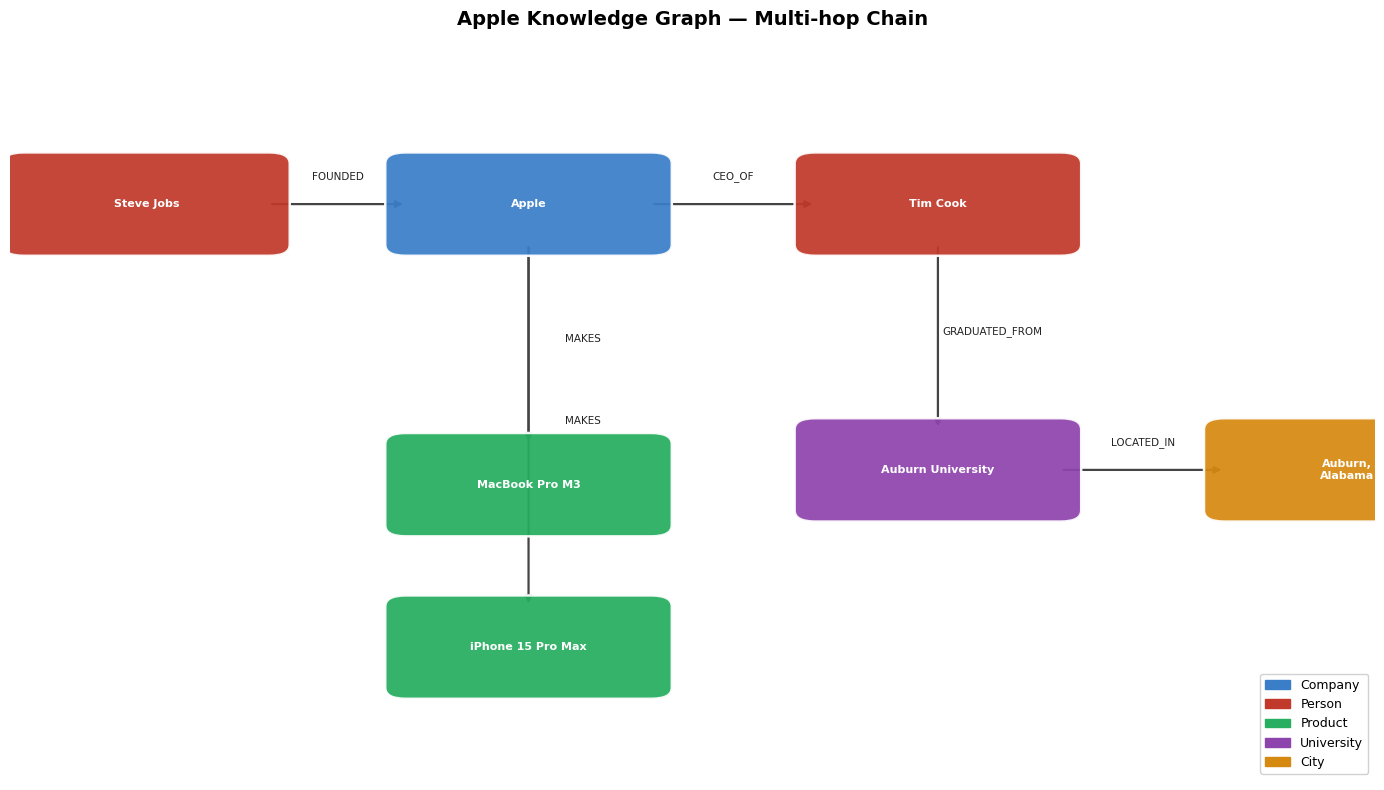

✅ Apple 知识图谱（流程图）绘制完成


In [14]:
## 🎨 Apple 知识图谱 — 流程图风格 / Flowchart-style Visualization

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def draw_flowchart(driver):
    """
    流程图风格，类似 ASCII 图：
    
    [Steve Jobs] ──FOUNDED──> [Apple] ──CEO_OF──> [Tim Cook]
                                 |                      |
                               MAKES             GRADUATED_FROM
                                 |                      |
                         [iPhone 15 Pro Max]     [Auburn Univ] ──LOCATED_IN──> [Auburn, AL]
                         [MacBook Pro M3]
    """
    # ── 从 Neo4j 取数据 ──────────────────────────────────────────
    with driver.session() as session:
        ceo = session.run(
            "MATCH (p:Person)-[:CEO_OF]->(c:Company {name:'Apple'}) "
            "RETURN p.name AS name, p.university AS uni, p.uni_city AS city, p.uni_state AS state"
        ).single()
        founders = [r["name"] for r in session.run(
            "MATCH (p:Person)-[:FOUNDED]->(c:Company {name:'Apple'}) RETURN p.name AS name"
        )]
        products = [r["name"] for r in session.run(
            "MATCH (c:Company {name:'Apple'})-[:MAKES]->(p:Product) RETURN p.name AS name"
        )]

    # ── 节点坐标 & 颜色 ──────────────────────────────────────────
    #   布局（axes fraction 坐标）
    #   行1 (y=0.78): [Founders...] ──FOUNDED──> [Apple] ──CEO_OF──> [Tim Cook]
    #   行2 (y=0.42): [Products...] (MAKES↓)     [Auburn Univ] ──LOCATED_IN──> [Auburn City]
    COL = {"Company": "#3A7EC8", "Person": "#C0392B", "Product": "#27AE60",
           "University": "#8E44AD", "City": "#D68910"}

    # Apple 固定在第一行中央
    APPLE_X, APPLE_Y = 0.38, 0.78

    nodes = {"Apple": (APPLE_X, APPLE_Y, COL["Company"])}

    # 创始人排在 Apple 左边（横向等间距）
    founder_xs = [APPLE_X - 0.28 * (i + 1) for i in range(len(founders))]
    for name, fx in zip(founders, founder_xs):
        nodes[name] = (fx, APPLE_Y, COL["Person"])

    # CEO 在 Apple 右边
    CEO_X, CEO_Y = APPLE_X + 0.30, APPLE_Y
    nodes[ceo["name"]] = (CEO_X, CEO_Y, COL["Person"])

    # 大学在 CEO 正下方
    UNI_X, UNI_Y = CEO_X, 0.42
    nodes[ceo["uni"]] = (UNI_X, UNI_Y, COL["University"])

    # 城市在大学右边
    CITY_X, CITY_Y = UNI_X + 0.30, UNI_Y
    city_label = f"{ceo['city']},\n{ceo['state']}"
    nodes[city_label] = (CITY_X, CITY_Y, COL["City"])

    # 产品在 Apple 正下方（纵向排列）
    prod_ys = [APPLE_Y - 0.38 - i * 0.22 for i in range(len(products))]
    for name, py in zip(products, prod_ys):
        nodes[name] = (APPLE_X, py, COL["Product"])

    # ── 边定义 ───────────────────────────────────────────────────
    edges = []
    for name in founders:
        edges.append((name, "Apple",      "FOUNDED",        "h"))
    edges.append(("Apple",       ceo["name"], "CEO_OF",         "h"))
    edges.append((ceo["name"],   ceo["uni"],  "GRADUATED_FROM", "v"))
    edges.append((ceo["uni"],    city_label,  "LOCATED_IN",     "h"))
    for name in products:
        edges.append(("Apple",   name,        "MAKES",          "v"))

    # ── 绘图 ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.set_xlim(0, 1); ax.set_ylim(0.05, 1.0)
    ax.axis("off")
    ax.set_title("Apple Knowledge Graph — Multi-hop Chain", fontsize=14,
                 fontweight="bold", pad=12)

    BOX_W, BOX_H = 0.18, 0.11

    def box_edge(key, side):
        """返回节点方框指定边的中心点。"""
        x, y, _ = nodes[key]
        if side == "right":  return (x + BOX_W / 2, y)
        if side == "left":   return (x - BOX_W / 2, y)
        if side == "top":    return (x, y + BOX_H / 2)
        if side == "bottom": return (x, y - BOX_H / 2)

    # 画节点方框
    for label, (x, y, color) in nodes.items():
        rect = FancyBboxPatch(
            (x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H,
            boxstyle="round,pad=0.015", linewidth=1.8,
            edgecolor="white", facecolor=color, alpha=0.93,
            transform=ax.transAxes, zorder=3,
        )
        ax.add_patch(rect)
        ax.text(x, y, label, ha="center", va="center", fontsize=8,
                fontweight="bold", color="white", transform=ax.transAxes,
                zorder=4, wrap=True, multialignment="center")

    # 画箭头 & 标签
    for src, dst, rel, orient in edges:
        if orient == "h":
            sx, sy = box_edge(src, "right")
            dx, dy = box_edge(dst, "left")
            mx, my = (sx + dx) / 2, sy + 0.03
        else:
            sx, sy = box_edge(src, "bottom")
            dx, dy = box_edge(dst, "top")
            mx, my = sx + 0.04, (sy + dy) / 2

        ax.annotate(
            "", xy=(dx, dy), xytext=(sx, sy),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="#444", lw=1.6,
                            connectionstyle="arc3,rad=0.0"),
            zorder=2,
        )
        ax.text(mx, my, rel, ha="center", va="bottom", fontsize=7.5,
                color="#222", transform=ax.transAxes, zorder=5,
                bbox=dict(fc="white", ec="none", alpha=0.85, pad=1.5))

    # 图例
    legend_items = [mpatches.Patch(color=c, label=k) for k, c in COL.items()]
    ax.legend(handles=legend_items, loc="lower right", fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()
    print("✅ Apple 知识图谱（流程图）绘制完成")


driver2 = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
draw_flowchart(driver2)
driver2.close()

---
## 🔍 查询一：单跳查询 / Single-Hop Query

**问题**：Apple 生产哪些产品？

**Cypher 语句**：
```cypher
MATCH (c:Company {name: 'Apple'})-[:MAKES]->(p:Product)
RETURN p.name AS product
```

**路径**：`Company` ──MAKES──▶ `Product`（1跳）

In [8]:
def query_single_hop(driver: Driver) -> None:
    print("  Query: Which products does Apple make?")
    with driver.session() as session:
        results = session.run(
            "MATCH (c:Company {name: 'Apple'})-[:MAKES]->(p:Product) RETURN p.name AS product"
        )
        for r in results:
            print(f"    → {r['product']}")


print("=" * 50)
print("SINGLE-HOP: Company -[MAKES]-> Product")
print("=" * 50)
query_single_hop(driver)

SINGLE-HOP: Company -[MAKES]-> Product
  Query: Which products does Apple make?
    → MacBook Pro M3
    → iPhone 15 Pro Max


---
## 🔗 查询二：双跳查询 / Two-Hop Query

**问题**：Apple 的 CEO 上过哪所大学？

**Cypher 语句**：
```cypher
MATCH (p:Person)-[:CEO_OF]->(c:Company {name: 'Apple'})
RETURN p.name AS ceo, p.university AS university
```

**推理链**（2跳）：
```
Person ──CEO_OF──▶ Company(Apple)
  └── .university 属性  ←── 第二跳（属性读取）
```

> 对比向量检索：单次向量查询无法同时检索到「苹果CEO是谁」和「他上哪所大学」两条文档并关联。

In [9]:
def query_two_hop(driver: Driver) -> None:
    print("  Query (2-hop): Apple CEO → university?")
    with driver.session() as session:
        results = session.run(
            "MATCH (p:Person)-[:CEO_OF]->(c:Company {name: 'Apple'}) "
            "RETURN p.name AS ceo, p.university AS university"
        )
        for r in results:
            print(f"    → {r['ceo']} attended {r['university']}")


print("=" * 50)
print("TWO-HOP: Person -[CEO_OF]-> Company → .university")
print("=" * 50)
query_two_hop(driver)

TWO-HOP: Person -[CEO_OF]-> Company → .university
  Query (2-hop): Apple CEO → university?
    → Tim Cook attended Auburn University


---
## 🗺️ 查询三：三跳查询 / Three-Hop Query

**问题**：Apple CEO 的大学在哪个城市？

**Cypher 语句**：
```cypher
MATCH (p:Person)-[:CEO_OF]->(c:Company {name: 'Apple'})
RETURN p.name AS ceo,
       p.university AS university,
       p.uni_city   AS city,
       p.uni_state  AS state
```

**推理链**（3跳）：
```
Apple → CEO(Tim Cook) → Auburn University → Auburn, Alabama
```

> 这正是上一节向量检索失败的场景！图查询一次遍历即可完成多跳推理。

In [10]:
def query_three_hop(driver: Driver) -> None:
    print("  Query (3-hop): In which city is Apple CEO's university located?")
    with driver.session() as session:
        results = session.run(
            "MATCH (p:Person)-[:CEO_OF]->(c:Company {name: 'Apple'}) "
            "RETURN p.name AS ceo, p.university AS university, "
            "       p.uni_city AS city, p.uni_state AS state"
        )
        for r in results:
            print(f"    → {r['ceo']}'s university ({r['university']}) is in {r['city']}, {r['state']}")


print("=" * 50)
print("THREE-HOP: Apple → CEO → University → City")
print("=" * 50)
query_three_hop(driver)

THREE-HOP: Apple → CEO → University → City
  Query (3-hop): In which city is Apple CEO's university located?
    → Tim Cook's university (Auburn University) is in Auburn, Alabama


---
## 关闭连接 & 总结 / Close & Summary

In [15]:
driver.close()
print("✅ Neo4j 连接已关闭")
print("\n知识图谱已就绪，可供后续 Pipeline 使用。")

✅ Neo4j 连接已关闭

知识图谱已就绪，可供后续 Pipeline 使用。


---
## 📊 总结 / Summary

### 知识图谱 vs 向量检索 对比

| 能力 | 向量检索 | 知识图谱 (Neo4j) |
|------|----------|------------------|
| 语义相似查询 | ✅ 强 | ❌ 弱 |
| 精确属性匹配 | ❌ 弱 | ✅ 强 |
| 多跳关系推理 | ❌ 无法跨文档 | ✅ 图遍历天然支持 |
| 结构化数据 | ❌ 需文本化 | ✅ 原生支持 |
| 可解释性 | ❌ 黑盒 | ✅ 路径可视化 |

### 核心洞察

```
向量检索  → 「找相似」
知识图谱  → 「跟关系走」
GraphRAG  → 两者结合：先用图找相关节点，再用向量做语义增强
```

**下一节将实现完整的 GraphRAG Pipeline：向量检索 + 图遍历 + LLM 生成。**